# Task 4: Predicting Insurance Claim Amounts

## Introduction

The objective of this task is to predict medical insurance charges based on personal information such as age, BMI, smoking status, number of children, sex, and region. A Linear Regression model will be used to estimate insurance charges, and the model's performance will be evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [3]:
insurance = pd.read_csv("../datasets/insurance.csv")

In [4]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
insurance.shape

(1338, 7)

In [6]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Dataset Overview

The insurance dataset contains personal information such as age, sex, BMI, number of children, smoking status, region, and medical insurance charges. The dataset will be explored and used to build a Linear Regression model for predicting insurance claim amounts.

## Exploratory Data Analysis (EDA)

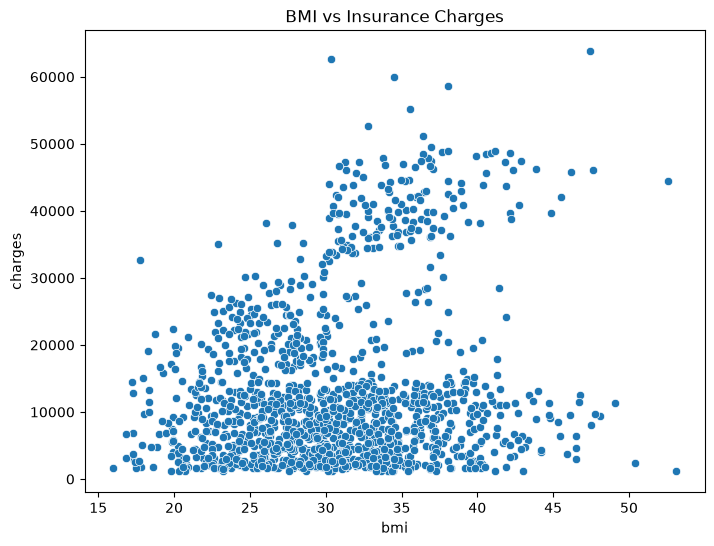

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=insurance, x="bmi", y="charges")

plt.title("BMI vs Insurance Charges")

plt.show()

### Observation

The scatter plot shows that insurance charges generally increase as BMI increases. Smokers and individuals with higher BMI tend to have significantly higher insurance costs.

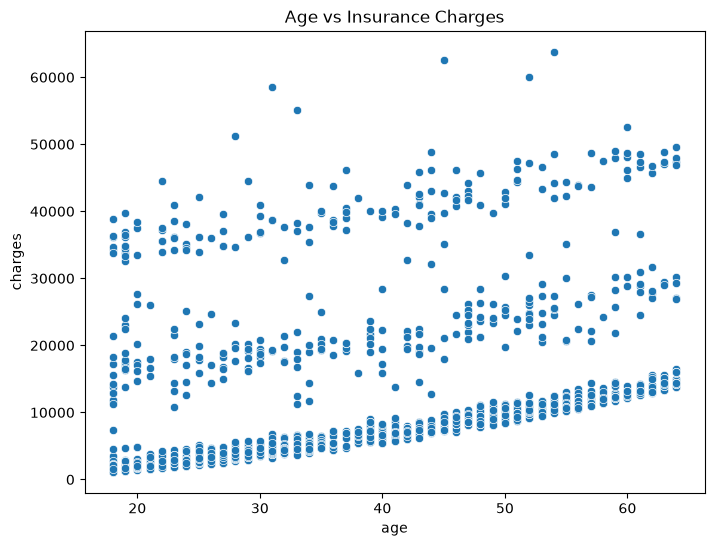

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=insurance, x="age", y="charges")

plt.title("Age vs Insurance Charges")

plt.show()

### Observation

The plot shows that insurance charges generally increase with age. Older individuals tend to have higher medical insurance costs.

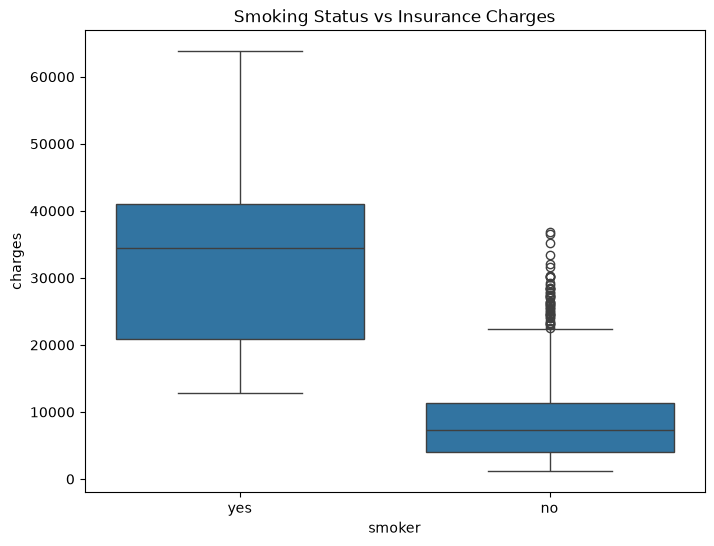

In [12]:
plt.figure(figsize=(8,6))

sns.boxplot(data=insurance, x="smoker", y="charges")

plt.title("Smoking Status vs Insurance Charges")

plt.show()

### Observation

Smokers have significantly higher insurance charges compared to non-smokers, indicating that smoking is a major factor affecting medical costs.

In [13]:
insurance = pd.get_dummies(insurance, drop_first=True)

X = insurance.drop("charges", axis=1)
y = insurance["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 4181.194473753649
Root Mean Squared Error: 5796.284659276273


## Conclusion

A Linear Regression model was successfully trained to predict medical insurance charges. Exploratory data analysis showed that age, BMI, and smoking status have a strong influence on insurance costs. The model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), providing an estimate of its prediction performance.